# Insurance Premium Forecasting

**Author:** Aman Bohra · Senior Analytics & BI Professional
**Portfolio:** https://amandbohra.github.io/portfolio/

Forecasting **Written Premium** is a staple of insurance analytics — it drives capacity planning,
target-setting, and distributor conversations. Here I build a transparent, dependency-light forecast
(trend + seasonality) on a **synthetic** monthly premium series and project the next 12 months.

> ⚠️ Synthetic data for demonstration only — no real or confidential client data.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.facecolor": "white", "axes.grid": True, "grid.alpha": 0.25})
rng = np.random.default_rng(7)


## 1. Generate 48 months of Written Premium
A rising trend, a repeating 12-month seasonal pattern, and random noise.

In [2]:
n = 48
t = np.arange(n)
dates = pd.date_range("2022-01-01", periods=n, freq="MS")
trend = 40 + 0.55 * t                              # $M, gently rising
season = 6 * np.sin(2*np.pi*(t % 12)/12) + 3*np.cos(2*np.pi*(t % 12)/6)
noise = rng.normal(0, 1.6, n)
premium = trend + season + noise
s = pd.Series(premium, index=dates, name="WrittenPremium")
s.head()


2022-01-01    43.001968
2022-02-01    45.527993
2022-03-01    44.357532
2022-04-01    43.225053
2022-05-01    45.168679
Freq: MS, Name: WrittenPremium, dtype: float64

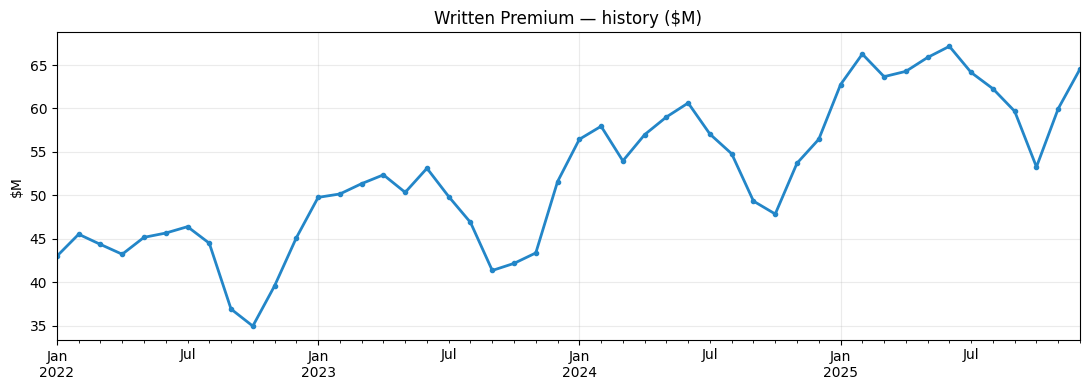

In [3]:
ax = s.plot(figsize=(11,4), color="#2386c8", lw=2, marker="o", ms=3)
ax.set_title("Written Premium — history ($M)"); ax.set_ylabel("$M"); plt.tight_layout(); plt.show()


## 2. Decompose: trend + seasonal profile
Estimate the trend with a centred 12-month moving average, then the average seasonal deviation per
calendar month.

In [4]:
ma = s.rolling(12, center=True).mean()
detrended = s - ma
seasonal = detrended.groupby(detrended.index.month).mean()
seasonal -= seasonal.mean()   # centre to zero
print("Seasonal profile ($M deviation by month):")
print(seasonal.round(2).to_string())


Seasonal profile ($M deviation by month):
1     3.66
2     4.97
3     2.68
4     3.59
5     3.62
6     4.94
7     1.64
8    -1.07
9    -7.83
10   -9.24
11   -5.94
12   -1.01


## 3. Forecast the next 12 months
Extrapolate the linear trend and add the seasonal profile back on. A simple, explainable baseline —
exactly the kind of forecast a business can interrogate.

In [5]:
# fit a linear trend on t
b1, b0 = np.polyfit(t, s.values, 1)
future_t = np.arange(n, n+12)
future_dates = pd.date_range(s.index[-1] + pd.offsets.MonthBegin(), periods=12, freq="MS")
trend_fc = b0 + b1*future_t
seas_fc = np.array([seasonal.loc[d.month] for d in future_dates])
forecast = pd.Series(trend_fc + seas_fc, index=future_dates, name="Forecast")

# simple band from historical residual spread
resid_std = (s - (b0 + b1*t) - np.array([seasonal.loc[d.month] for d in s.index])).std()
lower, upper = forecast - 1.96*resid_std, forecast + 1.96*resid_std
forecast.round(1)


2026-01-01    68.0
2026-02-01    69.8
2026-03-01    68.0
2026-04-01    69.4
2026-05-01    70.0
2026-06-01    71.8
2026-07-01    69.0
2026-08-01    66.7
2026-09-01    60.5
2026-10-01    59.5
2026-11-01    63.3
2026-12-01    68.8
Freq: MS, Name: Forecast, dtype: float64

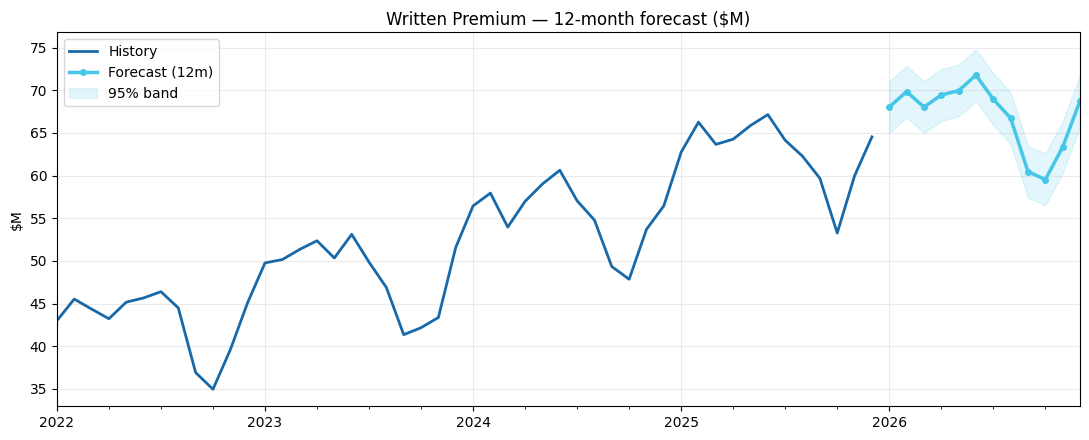

Next-12-months total forecast: $805M  (avg $67.1M/mo)


In [6]:
fig, ax = plt.subplots(figsize=(11,4.5))
s.plot(ax=ax, color="#1769aa", lw=2, label="History")
forecast.plot(ax=ax, color="#46c7e8", lw=2.5, marker="o", ms=4, label="Forecast (12m)")
ax.fill_between(forecast.index, lower, upper, color="#46c7e8", alpha=0.15, label="95% band")
ax.set_title("Written Premium — 12-month forecast ($M)"); ax.set_ylabel("$M"); ax.legend()
plt.tight_layout(); plt.show()
print(f"Next-12-months total forecast: ${forecast.sum():.0f}M  (avg ${forecast.mean():.1f}M/mo)")


## 4. Business value
- **Capacity & target setting** — a defensible monthly premium plan by region/line.
- **Early-warning** — actuals falling outside the band flag a conversation, not a fire drill.
- **Explainability** — trend and seasonality are separated, so leadership can see *why* the number moves.

The method is intentionally simple and auditable. In production I'd validate against holdout months and
compare with Holt-Winters / SARIMA — but a transparent baseline is often what the business will actually trust.

*— Aman Bohra*
